# CONCURSO NACIONAL OTTO DE GREIFF (XXIX EDICIÓN)

**Título de la investigación:** ENERGÍAS RENOVABLES PARA LA JUSTICIA ENERGÉTICA: UN ANÁLISIS DE POLÍTICA PARA LAS ZONAS NO INTERCONECTADAS

**Autor**: Tron

El presente cuaderno contiene el desarrollo metolodógico y estadístico de la investigación mencionada, en el marco de la versión No. 29 del Concurso Nacional Otto de Greiff, que premia los mejores trabajos de grado de pregrado del país. Con el fin de dar un análisis robusto, se lleva a cabo un análisis estadístico exploratorio (EDA) sobre las bases de datos elegidas, permitiendo observar de manera cuantitativa las características de la prestación del servicio de energía eléctrica en las Zonas No Intercontectadas (ZNI), su matriz  eléctrica y demás variables clave. 

**Objetivo general**

Analizar la prestación del servicio de energía eléctrica a través de Fuentes No Convencionales de Energía Renovable en las Zonas No Interconectadas.

**Objetivos específicos**

1) Describir procesos de gobernanza presentes en la adopción de proyectos de generación eléctrica a través de Fuentes No Convencionales de Energía Renovable en las ZNI. 
2) Caracterizar la prestación del servicio eléctrico en las ZNI 
3) Dar lineamientos de política para la adopción en FNCER en las ZNI.

## Bibliotecas

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
import squarify
import pandas as pd
import numpy as np
import plotly.express as px
import duckdb
import geopandas as gpd
import os
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import re

## Bases de datos

Para el análisis estadístico exploratorio, se utilizan las siguientes bases de datos, disponibles en el portal de *Datos Abiertos* de Colombia

| Nombre | Entidad | No. de registros (filas) | Fecha de actualización | Relevancia | Acceso |
|----------|-------------------|----------------------|----------------------|----------------------|----------|
| **Estado de la prestación del servicio de energía en Zonas No Interconectadas** | IPSE | 6.216 | 13/03/2026 | Permite caracterizar la prestación del servicio | [https://www.datos.gov.co/Minas-y-Energ-a/Estado-de-la-prestaci-n-del-servicio-de-energ-a-en/3ebi-d83g/about_data](https://www.datos.gov.co/Minas-y-Energ-a/Estado-de-la-prestaci-n-del-servicio-de-energ-a-en/3ebi-d83g/about_data) |
| **Superservicios - Registro de Generación Diaria - ZNI** | Superintendencia de Servicios Públicos | 2.222.487 | 24/05/2024 | Permite desagregar la matriz eléctrica | [https://www.datos.gov.co/Minas-y-Energ-a/Superservicios-Registro-de-Generacion-Diaria-ZNI/3a44-zwt6/about_data](https://www.datos.gov.co/Minas-y-Energ-a/Superservicios-Registro-de-Generacion-Diaria-ZNI/3a44-zwt6/about_data) |

### Recursos

In [4]:
df = pd.read_csv(r"C:\Users\qluis\Downloads\Estado_de_la_prestación_del_servicio_de_energía_en_Zonas_No_Interconectadas_20260630.csv")

In [5]:

df2 = pd.read_csv(r"C:\Users\qluis\Downloads\Superservicios_-_Registro_de_Generacion_Diaria_-_ZNI_20260630.csv")

C:\Users\qluis\AppData\Local\Temp\ipykernel_6172\2715220894.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv(r"C:\Users\qluis\Downloads\Superservicios_-_Registro_de_Generacion_Diaria_-_ZNI_20260630.csv")


### Preprocesamiento y limpieza

In [ ]:
df.info()

In [6]:

# 1. FUNCIÓN MAESTRA DE LIMPIEZA
# ==========================================
def limpieza_total_zni(df):
    # Crear copia para no alterar el original
    df_clean = df.copy()
    
    # ---------------------------------------------
    # A. LIMPIEZA NUMÉRICA TOTAL
    # ---------------------------------------------
    # Lista de todas las columnas numéricas posibles entre ambos datasets
    cols_num_posibles = [
        'ENERGÍA ACTIVA', 'ENERGÍA REACTIVA', 'POTENCIA MÁXIMA', 
        'PROMEDIO DIARIO EN HORAS', 'ENERGIA_GENERADA'
    ]
    
    for col in cols_num_posibles:
        if col in df_clean.columns:
            # 1. Quitar comas y puntos de miles si existen, forzar a texto primero
            df_clean[col] = df_clean[col].astype(str).str.replace(',', '.', regex=False)
            
            # 2. Convertir a flotante (texto basura se vuelve NaN)
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
            
            # 3. Tratamiento de nulos (Convertir NaN a 0)
            df_clean[col] = df_clean[col].fillna(0)
            
            # 4. Regla Lógica para el Promedio Diario de Horas:
            # Si supera 24 (error de origen), caparlo a 24 horas.
            if col == 'PROMEDIO DIARIO EN HORAS':
                df_clean.loc[df_clean[col] > 24, col] = 24.0

    # ---------------------------------------------
    # B. LIMPIEZA DE FECHAS Y HORAS
    # ---------------------------------------------
    if 'FECHA DE DEMANDA MÁXIMA' in df_clean.columns:
        df_clean['FECHA DE DEMANDA MÁXIMA'] = pd.to_datetime(
            df_clean['FECHA DE DEMANDA MÁXIMA'], format='mixed', dayfirst=True, errors='coerce'
        )
    
    if 'FECHA' in df_clean.columns:
        df_clean['FECHA'] = pd.to_datetime(df_clean['FECHA'], format='mixed', dayfirst=True, errors='coerce')
        
    if 'HORA_ENCENDIDO' in df_clean.columns:
        df_clean['HORA_ENCENDIDO'] = pd.to_datetime(df_clean['HORA_ENCENDIDO'], format='mixed', errors='coerce').dt.time
        
    if 'HORA_APAGADO' in df_clean.columns:
        df_clean['HORA_APAGADO'] = pd.to_datetime(df_clean['HORA_APAGADO'], format='mixed', errors='coerce').dt.time

    # ---------------------------------------------
    # C. LIMPIEZA DE CATEGÓRICOS, NULOS Y MEMORIA
    # ---------------------------------------------
    # Todas las variables categóricas posibles entre ambos datasets
    cols_cat_posibles = [
        'DEPARTAMENTO', 'MUNICIPIO', 'LOCALIDAD', 'DÍA DE DEMANDA MÁXIMA',
        'COD_LOCALIDAD', 'TIPO_ELEMENTO', 'SERIAL_ELEMENTO', 'TIPO_TECNOLOGIA',
        'TIPO_MEDICION', 'CAUSAL_NO_GEN', 'IDENTIFICADOR_EMPRESA', 'EMPRESA', 'MES'
    ]
    
    # Tabla de traducción para eliminar tildes de forma rápida y segura
    tabla_tildes = str.maketrans('ÁÉÍÓÚáéíóú', 'AEIOUaeiou')
    
    for col in cols_cat_posibles:
        if col in df_clean.columns:
            # Reemplazar nulos de texto y 'nan' literales por 'No registrado'
            df_clean[col] = df_clean[col].astype(str).replace(['nan', 'NaN', 'None', ''], 'No registrado')
            df_clean[col] = df_clean[col].fillna('No registrado')
            
            # --- NUEVO: Quitar tildes para evitar duplicados ortográficos leves ---
            df_clean[col] = df_clean[col].str.translate(tabla_tildes)
            
            # Optimizar memoria pasando a category (baja dimensionalidad)
            df_clean[col] = df_clean[col].astype('category')
            
    # Forzar año a entero (dataset 2)
    if 'ANNO' in df_clean.columns:
        df_clean['ANNO'] = pd.to_numeric(df_clean['ANNO'], errors='coerce').astype('Int64')

    # Eliminar filas completamente duplicadas (si existen)
    df_clean = df_clean.drop_duplicates()
            
    return df_clean

# ==========================================
# 2. APLICAR LIMPIEZA A AMBOS DATASETS
# ==========================================
# Asumo que tus variables originales se llaman 'df' (IPSE) y 'df2' (Superservicios)
df_ipse_limpio = limpieza_total_zni(df)
df_superservicios_limpio = limpieza_total_zni(df2)

# ==========================================
# 3. VERIFICACIÓN FINAL SILENCIOSA
# ==========================================
print("--- RESUMEN DE LIMPIEZA IPSE ---")
print(f"Total registros: {len(df_ipse_limpio)}")
print(f"Max Horas Promedio: {df_ipse_limpio.get('PROMEDIO DIARIO EN HORAS', pd.Series([0])).max()} (Máximo 24.0)")
print(f"Memoria (MB): {df_ipse_limpio.memory_usage(deep=True).sum() / 1e6:.2f}")

print("\n--- RESUMEN DE LIMPIEZA SUPERSERVICIOS ---")
print(f"Total registros: {len(df_superservicios_limpio)}")
print(f"Memoria (MB): {df_superservicios_limpio.memory_usage(deep=True).sum() / 1e6:.2f}")

--- RESUMEN DE LIMPIEZA IPSE ---
Total registros: 6215
Max Horas Promedio: 24.0 (Máximo 24.0)
Memoria (MB): 0.64

--- RESUMEN DE LIMPIEZA SUPERSERVICIOS ---
Total registros: 2222487
Memoria (MB): 294.96


## Estado de la prestación del servicio de energía eléctrica

### Consultas SQL

La presente consulta permite ver el desempeño de los departamentos en variables clave. 

In [4]:
query_sql = """
SELECT 
    UPPER(TRIM("DEPARTAMENTO")) AS departamento_nombre,
    AVG("PROMEDIO DIARIO EN HORAS") AS horas_promedio_diario,
    AVG("ENERGÍA ACTIVA") AS energia_activa_promedio,
    AVG("POTENCIA MÁXIMA") AS potencia_max_promedio
FROM df_ipse_limpio
WHERE "AÑO SERVICIO" = 2025
  AND "PROMEDIO DIARIO EN HORAS" > 0 
GROUP BY UPPER(TRIM("DEPARTAMENTO"))
ORDER BY horas_promedio_diario
"""

# Ejecutar la consulta y convertir el resultado a un nuevo DataFrame
df_2025_sql = duckdb.sql(query_sql).df()
df_2025_sql.head(32)


,departamento_nombre,horas_promedio_diario,energia_activa_promedio,potencia_max_promedio
0,LA GUAJIRA,4.847237,26.858500,211.698750
1,ANTIOQUIA,6.823630,129.250528,27.209849
2,CAQUETÁ,6.833119,58.602923,64.721038
3,CAUCA,7.784285,8.326960,47.572099
4,NARIÑO,7.846121,72.058472,37.581981
5,BOLÍVAR,9.654152,9.362143,44.325524
6,VALLE DEL CAUCA,9.691027,34.410985,55.621330
7,CHOCÓ,11.497406,148.171660,95.448279
8,PUTUMAYO,14.626175,424.439917,30.800000
9,GUAVIARE,16.535492,67.990208,169.713917


In [6]:
query_promedio_general = """
SELECT 
    AVG("PROMEDIO DIARIO EN HORAS") AS promedio_diario_nacional_2025
FROM df_ipse_limpio
WHERE "AÑO SERVICIO" = 2025
  AND "PROMEDIO DIARIO EN HORAS" > 0;
"""

# Ejecutamos la consulta y la mostramos
promedio_general_df = duckdb.sql(query_promedio_general).df()
print(promedio_general_df)

   promedio_diario_nacional_2025
0                      11.398496


In [ ]:
df_ipse_limpio.head()

### Mapa de coroplétas

In [8]:
ruta_shp = r"C:\Users\qluis\Downloads\MGN2024_DPTO_POLITICO"

# Cargar el archivo
mapa_colombia = gpd.read_file(ruta_shp)

def limpiar_tildes(texto):
    return str(texto).replace('Á','A').replace('É','E').replace('Í','I').replace('Ó','O').replace('Ú','U').strip().upper()

mapa_colombia['dpto_cnmbr'] = mapa_colombia['dpto_cnmbr'].apply(limpiar_tildes)
df_2025_sql['departamento_nombre'] = df_2025_sql['departamento_nombre'].apply(limpiar_tildes)

# ==========================================
# 2. ELIMINAR SAN ANDRÉS PARA MEJORAR ZOOM
# ==========================================
# Filtramos el Shapefile para quitar San Andrés y Providencia y forzar un mejor encuadre continental
mapa_colombia = mapa_colombia[mapa_colombia['dpto_cnmbr'] != 'ARCHIPIELAGO DE SAN ANDRES Y PROVIDENCIA']

# Realizar el cruce (Join)
mapa_final = mapa_colombia.merge(
    df_2025_sql, 
    left_on='dpto_cnmbr', 
    right_on='departamento_nombre', 
    how='left'
)

# ==========================================
# 3. GRAFICAR EN ALTA CALIDAD (SIN TÍTULO, BARRA VERTICAL)
# ==========================================
# Aumentamos el DPI interno y usamos un tamaño óptimo
fig, ax = plt.subplots(1, 1, figsize=(10, 12), dpi=300)

# Herramienta para ajustar el tamaño de la barra de color (leyenda vertical) exactamente al mapa
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)

mapa_final.plot(
    column='horas_promedio_diario',
    cmap='RdYlGn',             # Rojo a Verde
    linewidth=0.5,             # Líneas más finas para mayor elegancia
    ax=ax,
    cax=cax,                   # Asignar la barra vertical ajustada
    edgecolor='black',
    legend=True,
    legend_kwds={
        'label': "Promedio Diario de Servicio (Horas)", 
        'orientation': "vertical"  # Barra vertical
    },
    missing_kwds={
        "color": "#e0e0e0",    # Gris suave elegante para departamentos sin datos
        "hatch": "///",        # Opcional: añade un tramado rayado para distinguirlos mejor
        "label": "Sin Datos"
    }
)

# Quitar ejes y bordes
ax.axis('off')

# Asegurar que los márgenes sean lo más ajustados posibles para no dejar espacios en blanco
plt.tight_layout()

# ==========================================
# 4. EXPORTAR A SVG VECTORIAL DE ALTA CALIDAD
# ==========================================
nombre_archivo = "mapa_colombia_zni_2025.svg"
plt.savefig(
    nombre_archivo, 
    format='svg', 
    bbox_inches='tight', # Recorta los bordes blancos sobrantes
    transparent=True     # Fondo transparente, excelente para insertar en documentos
)

print(f"✅ Mapa exportado en Alta Calidad como: {nombre_archivo}")

# Mostrar también en pantalla
plt.show()

NameError: name 'df_2025_sql' is not defined

### Mapa interactivo

### Matriz de correlación

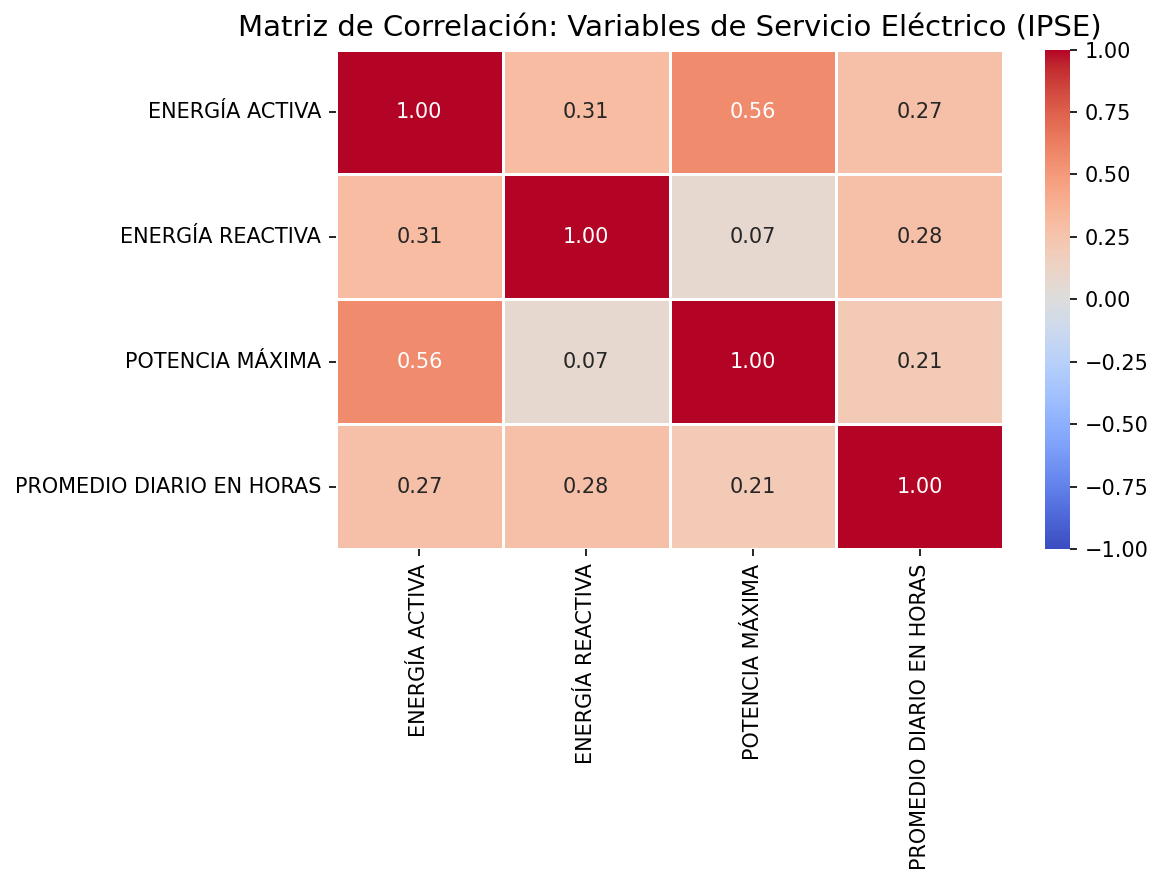

In [8]:
# Seleccionar solo las variables numéricas del dataset IPSE
cols_numericas = ['ENERGÍA ACTIVA', 'ENERGÍA REACTIVA', 'POTENCIA MÁXIMA', 'PROMEDIO DIARIO EN HORAS']
df_corr = df_ipse_limpio[cols_numericas]

# Calcular la matriz de correlación (método de Spearman es mejor si hay valores atípicos/no lineales)
matriz_correlacion = df_corr.corr(method='spearman')

# Graficar un Mapa de Calor (Heatmap)
plt.figure(figsize=(8, 6), dpi=150)
sns.heatmap(
    matriz_correlacion, 
    annot=True,          # Mostrar los números
    fmt=".2f",           # 2 decimales
    cmap="coolwarm",     # Rojo: Correlación positiva, Azul: Negativa
    vmin=-1, vmax=1, 
    linewidths=0.5
)

plt.title("Matriz de Correlación: Variables de Servicio Eléctrico (IPSE)", fontsize=14)
plt.tight_layout()
plt.show()

### Modelo K-means


--- PERFILES DE RIESGO ENERGÉTICO DESCUBIERTOS (DATOS LIMPIOS) ---
         CANTIDAD_MUNICIPIOS  PROMEDIO_HORAS  PROMEDIO_ENERGIA  \
CLUSTER                                                          
1                         39            8.05             37.06   
3                         16           19.05            106.52   
0                          7           11.86            294.90   
2                          2           22.83            333.43   

         PROMEDIO_POTENCIA  
CLUSTER                     
1                    65.70  
3                   163.63  
0                    83.79  
2                   678.09  


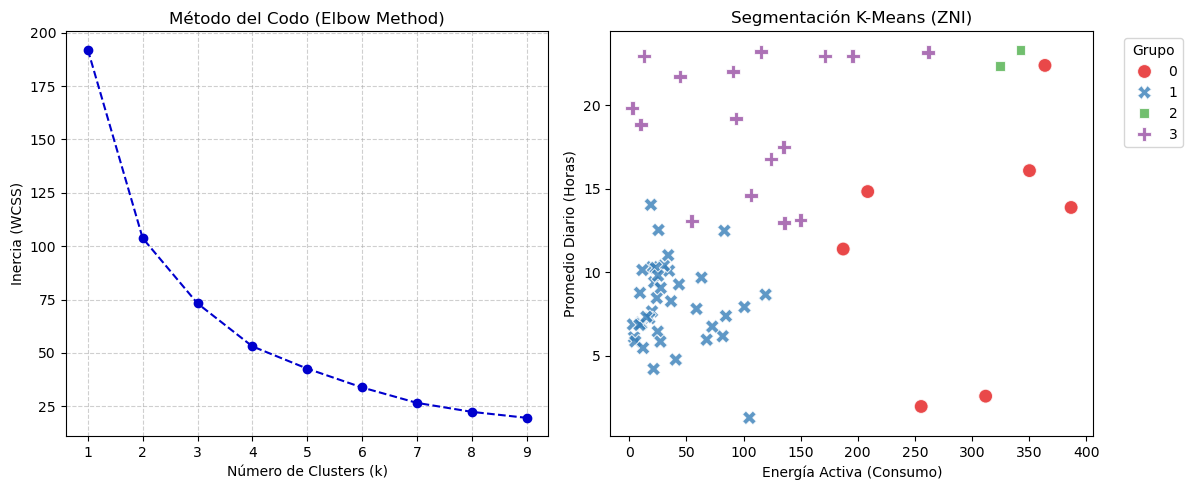


--- LISTA DEFINITIVA DE MUNICIPIOS POR CLÚSTER ---

🔹 CLÚSTER 1 (39 municipios):
BAJO BAUDO, BOJAYA, BOJAYA (BELLAVISTA), BUENAVENTURA, CARTAGENA, CARTAGENA DE INDIAS, CARTAGENA DEL CHAIRA, CARURU, EL CHARCO, EL LITORAL DEL SAN JUAN, FRANCISCO PIZARRO, GUAPI, ISTMINA, LA TOLA, LOPEZ (MICAY), LOPEZ DE MICAY, MEDIO ATRATO, MEDIO ATRATO (BETE), MEDIO SAN JUAN, MOSQUERA, NOVITA, OLAYA HERRERA, QUIBDO, RIOSUCIO, ROBERTO PAYAN, SAN ANDRES DE TUMACO, SAN JOSE DEL GUAVIARE, SAN VICENTE DEL CAGUAN, SANTA BARBARA, SANTA BARBARA (ISCUANDE), SIPI, TARAIRA, TARAPACA, TARAPACA (ANM), TIMBIQUI, TRINIDAD, TUMACO, URIBIA, VIGIA DEL FUERTE

🔹 CLÚSTER 3 (16 municipios):
ALTO BAUDO (PIE DE PATO), BAHIA SOLANO (MUTIS), BAJO BAUDO (PIZARRO), BARRANCO MINAS, BARRANCOMINAS, CIENAGA, INIRIDA, JURADO, MAPIRIPAN, MIRAFLORES, MITU, PROVIDENCIA, PUERTO CARREÑO, PUERTO NARIÑO, SANTA ROSALIA, UNGUIA

🔹 CLÚSTER 0 (7 municipios):
ACANDI, ALTO BAUDO, BAHIA SOLANO, MAGÜI, NUQUI, PUERTO LEGUIZAMO, RIO QUITO

🔹 CLÚSTER 2

In [ ]:
# 1. PREPARACIÓN DE DATOS 
# ==========================================
df_kmeans = df_ipse_limpio.groupby('MUNICIPIO', observed=False).agg(
    ENERGIA_ACTIVA=('ENERGÍA ACTIVA', 'mean'),
    POTENCIA_MAXIMA=('POTENCIA MÁXIMA', 'mean'),
    HORAS_SERVICIO=('PROMEDIO DIARIO EN HORAS', 'mean')
).dropna()

df_kmeans = df_kmeans[(df_kmeans['ENERGIA_ACTIVA'] > 0) & (df_kmeans['HORAS_SERVICIO'] > 0)]

# ==========================================
# 2. ESCALADO
# ==========================================
scaler = StandardScaler()
datos_escalados = scaler.fit_transform(df_kmeans)

# ==========================================
# 3. MÉTODO DEL CODO (CÁLCULO DE INERCIA)
# ==========================================
inercia = []
rango_k = range(1, 10)

for k in rango_k:
    modelo_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo_temp.fit(datos_escalados)
    inercia.append(modelo_temp.inertia_)

# ==========================================
# 4. ENTRENAMIENTO DEL MODELO DEFINITIVO
# ==========================================
k_optimo = 4 
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df_kmeans['CLUSTER'] = kmeans_final.fit_predict(datos_escalados)

perfiles = df_kmeans.groupby('CLUSTER').agg(
    CANTIDAD_MUNICIPIOS=('HORAS_SERVICIO', 'count'),
    PROMEDIO_HORAS=('HORAS_SERVICIO', 'mean'),
    PROMEDIO_ENERGIA=('ENERGIA_ACTIVA', 'mean'),
    PROMEDIO_POTENCIA=('POTENCIA_MAXIMA', 'mean')
).round(2).sort_values(by='PROMEDIO_ENERGIA')

print("\n--- PERFILES DE RIESGO ENERGÉTICO DESCUBIERTOS (DATOS LIMPIOS) ---")
print(perfiles)

# ==========================================
# 5. VISUALIZACIÓN: CODO Y CLÚSTERES JUNTOS
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Gráfica 1: Método del Codo
ax1.plot(rango_k, inercia, marker='o', linestyle='--', color='mediumblue')
ax1.set_title('Método del Codo (Elbow Method)')
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inercia (WCSS)')
ax1.grid(True, linestyle='--', alpha=0.6)

# Gráfica 2: Scatter Plot de Segmentación
sns.scatterplot(
    data=df_kmeans, 
    x='ENERGIA_ACTIVA', 
    y='HORAS_SERVICIO', 
    hue='CLUSTER', 
    palette='Set1', 
    style='CLUSTER',
    s=100, alpha=0.8,
    ax=ax2
)
ax2.set_title('Segmentación K-Means (ZNI)')
ax2.set_xlabel('Energía Activa (Consumo)')
ax2.set_ylabel('Promedio Diario (Horas)')
ax2.legend(title='Grupo', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# ==========================================
# 6. IMPRIMIR MUNICIPIOS POR GRUPO
# ==========================================
print("\n--- LISTA DE MUNICIPIOS POR CLÚSTER ---")
for i in perfiles.index:
    municipios = df_kmeans[df_kmeans['CLUSTER'] == i].index.tolist()
    municipios.sort()
    print(f"\n🔹 CLÚSTER {i} ({len(municipios)} municipios):")
    print(", ".join(municipios))

## Registros de generación y capacidad instalada

### Matriz eléctrica

In [18]:
# 1. Configuración de tema (limpio, sin logos)
pio.templates.default = "plotly_white"

# 2. Datos jerárquicos
# Las etiquetas incluyen los nombres y los valores con separador de miles
labels = [
    "ZNI<br>335.271 kW", 
    "Diésel<br>262.056 kW", 
    "FNCER<br>73.215 kW", 
    "Solar FV<br>Individual<br>54.701 kW", 
    "Solar FV<br>Concentrado<br>8.381 kW", 
    "Pequeñas<br>Hidro<br>4.613 kW", 
    "Biomasa<br>4.520 kW", 
    "Residuos<br>Sólidos<br>1.000 kW"
]

# Definición de la jerarquía (quién es padre de quién)
parents = [
    "",                             # Raíz
    "ZNI<br>335.271 kW",            # Hijo de ZNI
    "ZNI<br>335.271 kW",            # Hijo de ZNI
    "FNCER<br>73.215 kW",           # Hijo de FNCER
    "FNCER<br>73.215 kW",           # Hijo de FNCER
    "FNCER<br>73.215 kW",           # Hijo de FNCER
    "FNCER<br>73.215 kW",           # Hijo de FNCER
    "FNCER<br>73.215 kW"            # Hijo de FNCER
]

# Valores absolutos
values = [335271, 262056, 73215, 54701, 8381, 4613, 4520, 1000]

# 3. Mapeo de colores estético y profesional
# Gris para diésel, azules y verdes para renovables
colors = [
    "#ffffff",  # ZNI (fondo de raíz, no se ve)
    "#595959",  # Diésel (Gris oscuro)
    "#2ca02c",  # FNCER (Verde base)
    "#1f77b4",  # Solar individual (Azul)
    "#4fa3d9",  # Solar concentrado (Azul claro)
    "#66bb6a",  # Pequeñas hidro (Verde claro)
    "#8c564b",  # Biomasa (Marrón/Tierra)
    "#ffa726"   # RSU (Naranja)
]

# 4. Creación de la figura
fig = go.Figure(go.Treemap(
    labels=labels,
    parents=parents,
    values=values,
    branchvalues="total", # Permite que el tamaño del padre sea la suma exacta de los hijos
    textinfo="label+percent parent", # Muestra el texto y qué % representa de su categoría superior
    marker=dict(
        colors=colors,
        line=dict(width=2, color="#ffffff") # Borde blanco elegante entre los cuadros
    ),
    textfont=dict(size=15, color="white", family="Arial, sans-serif"),
    pathbar=dict(visible=False), # Oculta la barra de navegación superior
    hovertemplate="<b>%{label}</b><br>Participación total: %{percentRoot:.1%}<extra></extra>"
))

# 5. Ajustes de diseño (Sin títulos, notas, y con márgenes mínimos)
fig.update_layout(
    margin=dict(t=10, l=10, r=10, b=10), # Márgenes al mínimo para aprovechar todo el espacio
    width=1000, 
    height=600
)

# Mostrar en el entorno interactivo
fig.show()

# Guardar como imagen PNG en alta calidad (escala 3x para evitar pixelado en artículos)
fig.write_image("treemap_matriz_zni_limpio.png", scale=3)

In [9]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.io as pio
import pandas as pd

# =========================================================
# Figura profesional en dos paneles:
# 1) ZNI: Diésel vs FNCER
# 2) Desglose interno de FNCER
# =========================================================

pio.templates.default = "plotly_white"

# ---------------------------------------------------------
# 1. Datos base tomados del bloque original del cuaderno
# ---------------------------------------------------------
total_zni = 335271
kw_diesel = 262056
kw_fncer = 73215

df_principal = pd.DataFrame({
    "fuente": ["Diésel", "FNCER"],
    "kw": [kw_diesel, kw_fncer]
})

df_principal["porcentaje_total"] = (df_principal["kw"] / total_zni) * 100

df_fncer = pd.DataFrame({
    "fuente": [
        "Solar FV - Individual",
        "Solar FV - Concentrado",
        "Pequeñas hidro",
        "Biomasa",
        "Residuos sólidos"
    ],
    "kw": [54701, 8381, 4613, 4520, 1000]
})

df_fncer["porcentaje_fncer"] = (df_fncer["kw"] / kw_fncer) * 100
df_fncer["porcentaje_total"] = (df_fncer["kw"] / total_zni) * 100

# Orden visual
df_principal = df_principal.sort_values("kw", ascending=True)
df_fncer = df_fncer.sort_values("kw", ascending=True)

# ---------------------------------------------------------
# 2. Etiquetas de texto
# ---------------------------------------------------------
df_principal["texto"] = df_principal.apply(
    lambda row: f"{row['kw']:,.0f} kW | {row['porcentaje_total']:.1f}% del total",
    axis=1
)

df_fncer["texto"] = df_fncer.apply(
    lambda row: (
        f"{row['kw']:,.0f} kW | "
        f"{row['porcentaje_fncer']:.1f}% de FNCER | "
        f"{row['porcentaje_total']:.1f}% del total"
    ),
    axis=1
)

# ---------------------------------------------------------
# 3. Figura con subplots
# ---------------------------------------------------------
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=False,
    vertical_spacing=0.18,
    row_heights=[0.38, 0.62],
    subplot_titles=(
        "Composición principal de la capacidad instalada en ZNI",
        "Desglose interno de Fuentes No Convencionales de Energía Renovable (FNCER)"
    )
)

# Panel 1: Diésel vs FNCER
fig.add_trace(
    go.Bar(
        x=df_principal["kw"],
        y=df_principal["fuente"],
        orientation="h",
        marker=dict(color=["#2ca02c", "#595959"]),
        text=df_principal["texto"],
        textposition="outside",
        cliponaxis=False,
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Capacidad: %{x:,.0f} kW<br>"
            "<extra></extra>"
        ),
        showlegend=False
    ),
    row=1, col=1
)

# Panel 2: desglose FNCER
fig.add_trace(
    go.Bar(
        x=df_fncer["kw"],
        y=df_fncer["fuente"],
        orientation="h",
        marker=dict(
            color=["#8c564b", "#66bb6a", "#4fa3d9", "#1f77b4", "#ffa726"]
        ),
        text=df_fncer["texto"],
        textposition="outside",
        cliponaxis=False,
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Capacidad: %{x:,.0f} kW<br>"
            "<extra></extra>"
        ),
        showlegend=False
    ),
    row=2, col=1
)

# ---------------------------------------------------------
# 4. Ajustes de diseño
# ---------------------------------------------------------
fig.update_layout(
    width=1250,
    height=820,
    margin=dict(t=90, l=60, r=320, b=50),
    paper_bgcolor="white",
    plot_bgcolor="white",
    font=dict(
        family="Arial, sans-serif",
        size=13,
        color="#222222"
    )
)

fig.update_xaxes(
    title_text="Capacidad instalada (kW)",
    showgrid=True,
    gridcolor="#d9d9d9",
    zeroline=False,
    row=1, col=1
)

fig.update_xaxes(
    title_text="Capacidad instalada (kW)",
    showgrid=True,
    gridcolor="#d9d9d9",
    zeroline=False,
    row=2, col=1
)

fig.update_yaxes(title_text="", row=1, col=1)
fig.update_yaxes(title_text="", row=2, col=1)

# Afinar estilo de subtítulos
fig.layout.annotations[0].font = dict(size=15, color="#222222")
fig.layout.annotations[1].font = dict(size=15, color="#222222")

# Mostrar
fig.show()

# Exportar en alta calidad
fig.write_image("matriz_zni_dos_paneles_profesional.png", scale=3)